In [1]:
# ==============================================================================
# CELL 0 & 1: BOOTSTRAP & CORE FILTERING (CODESPACE READY)
# ==============================================================================

import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=UserWarning)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine

# --- 1. CONNECTIVITY ---
DB_PATH = '/workspaces/pienza/data/pienza.db'

if not os.path.exists(DB_PATH):
    print(f"🔴 CRITICAL: Database not found at {DB_PATH}")
else:
    db_engine = create_engine(f'sqlite:///{DB_PATH}')
    print("✅ SQL Engine Active.")

# --- 2. OPUS THEME ---
OPUS_PURPLE = '#440154'
OPUS_TEAL   = '#21918c'
OPUS_GREY   = '#FAFAFA'
OPUS_TEXT   = '#121212'

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'figure.facecolor': OPUS_GREY, 'axes.facecolor': OPUS_GREY, 'text.color': OPUS_TEXT,
    'xtick.color': '#333333', 'ytick.color': '#333333', 'axes.edgecolor': '#DDDDDD',
    'grid.color': '#E0E0E0', 'font.family': 'sans-serif'
})

# --- 3. DATA INGESTION (VIABLE OFFERS ONLY) ---
print("⏳ Fetching core data...")
df_offers_raw = pd.read_sql("SELECT * FROM offers", db_engine)
df_reasons = pd.read_sql("SELECT reason_primary_id, reason_primary_description FROM reason_primary", db_engine)

# Get Geo-Veto ID and Filter
geo_veto_id = df_reasons[df_reasons['reason_primary_description'] == 'dropoff_non_operational']['reason_primary_id'].iloc[0]
df_analysis = df_offers_raw[df_offers_raw['reason_primary_fk'] != geo_veto_id].copy()

print(f"✅ Filtered out Geo-Vetoes. Analytical base ready: {len(df_analysis)} offers.")

✅ SQL Engine Active.
⏳ Fetching core data...
✅ Filtered out Geo-Vetoes. Analytical base ready: 2399 offers.


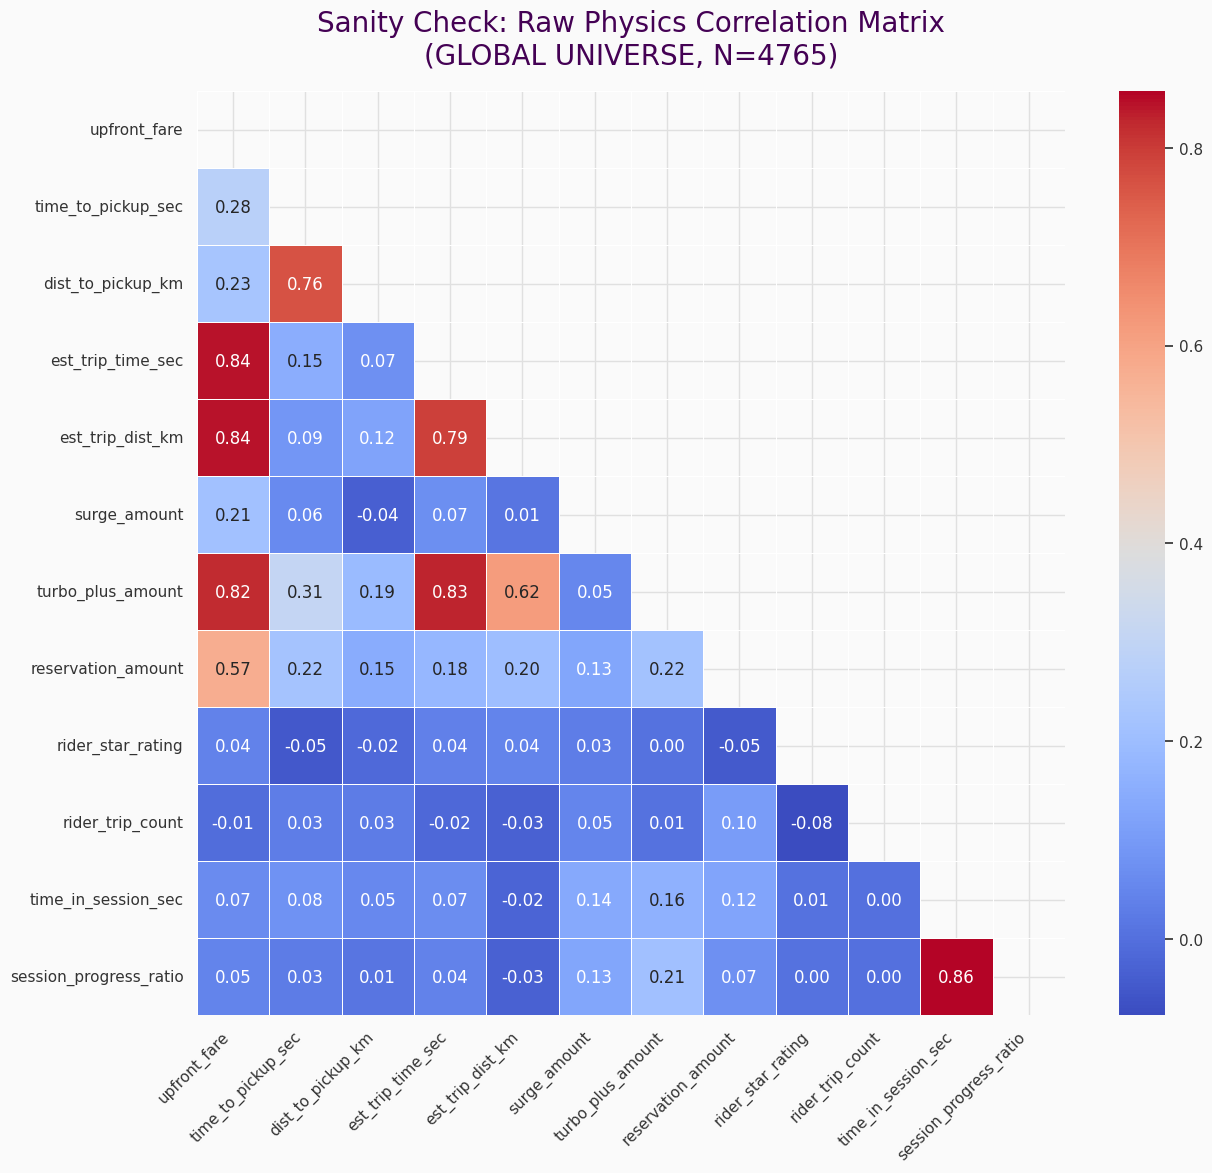

In [4]:
# ==============================================================================
# CELL 2: SANITY CHECK - "RAW PHYSICS" CORRELATION MATRIX (GLOBAL UNIVERSE)
# ==============================================================================
# Purpose: Re-generate the original correlation heatmap on the FULL dataset
#          to investigate the anomalous -0.50 correlation of Rider Star Rating.
# ==============================================================================

# --- Define the "Raw Physics" columns ---
physics_cols = [
    'upfront_fare',
    'time_to_pickup_sec',
    'dist_to_pickup_km',
    'est_trip_time_sec',
    'est_trip_dist_km',
    'surge_amount',
    'turbo_plus_amount',
    'reservation_amount',
    'rider_star_rating',
    'rider_trip_count',
    'time_in_session_sec',
    'session_progress_ratio'
]

# --- Calculate the correlation matrix ON THE RAW, UNFILTERED DATA ---
corr_matrix_physics = df_offers_raw[physics_cols].corr()

# --- Visualize the heatmap ---
plt.figure(figsize=(14, 12))

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(corr_matrix_physics, dtype=bool))

sns.heatmap(corr_matrix_physics,
            mask=mask,
            annot=True,
            cmap='coolwarm',
            fmt=".2f",
            linewidths=.5)

plt.title('Sanity Check: Raw Physics Correlation Matrix\n(GLOBAL UNIVERSE, N=4765)', fontsize=20, pad=20, color=OPUS_PURPLE)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.show()

⏳ Architecting the Unified DataFrame (Mega-Matrix)...
✅ Unified DataFrame created. Shape: (4765, 30)
⏳ Calculating the Grand Unified Correlation Matrix...
🎨 Rendering the Mega-Heatmap...


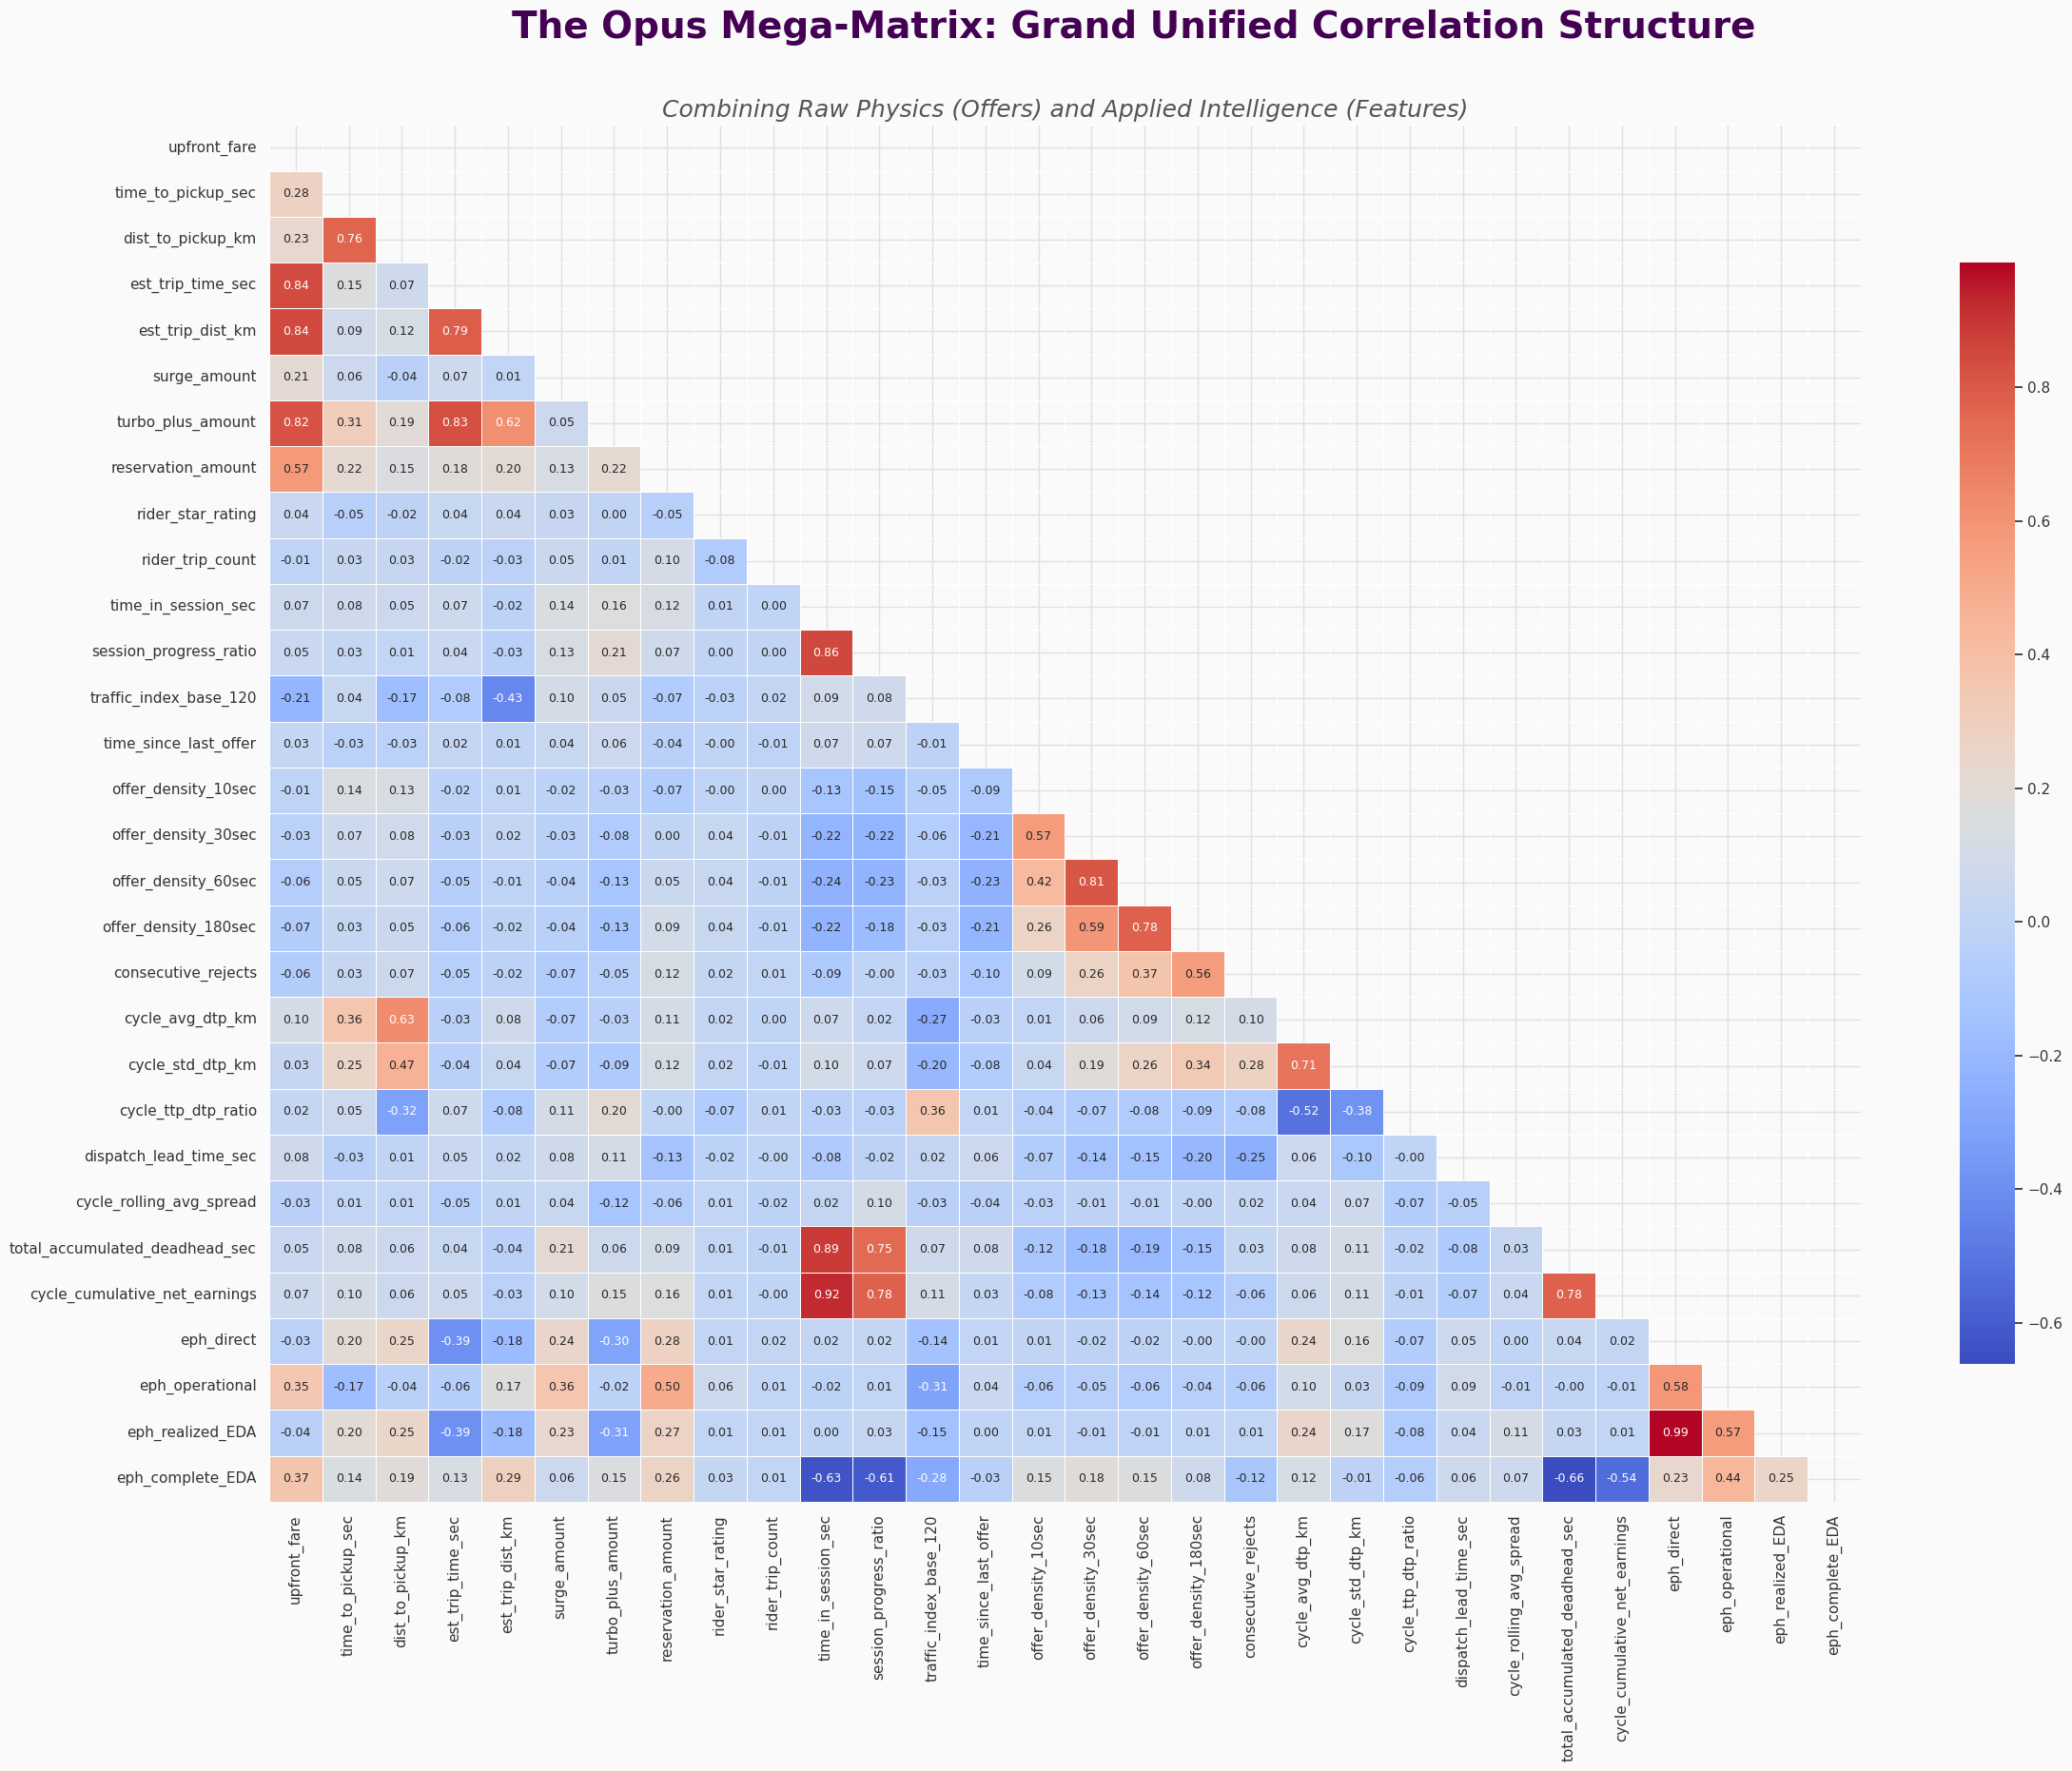

In [8]:
# ==============================================================================
# CELL 3: THE GRAND UNIFIED CORRELATION MATRIX (MEGA-HEATMAP)
# ==============================================================================

print("⏳ Architecting the Unified DataFrame (Mega-Matrix)...")

mega_query = """
SELECT
    o.upfront_fare, o.time_to_pickup_sec, o.dist_to_pickup_km, o.est_trip_time_sec,
    o.est_trip_dist_km, o.surge_amount, o.turbo_plus_amount, o.reservation_amount,
    o.rider_star_rating, o.rider_trip_count, o.time_in_session_sec, o.session_progress_ratio,
    ef.traffic_index_base_120, ef.time_since_last_offer, ef.offer_density_10sec,
    ef.offer_density_30sec, ef.offer_density_60sec, ef.offer_density_180sec,
    ef.consecutive_rejects, ef.cycle_avg_dtp_km, ef.cycle_std_dtp_km, ef.cycle_ttp_dtp_ratio,
    ef.dispatch_lead_time_sec, ef.cycle_rolling_avg_spread, ef.total_accumulated_deadhead_sec,
    ef.cycle_cumulative_net_earnings, ef.eph_direct, ef.eph_operational,
    ef.eph_realized_EDA, ef.eph_complete_EDA
FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
"""

df_mega = pd.read_sql(mega_query, db_engine)
print(f"✅ Unified DataFrame created. Shape: {df_mega.shape}")

# 1. CALCULATE CORRELATION
print("⏳ Calculating the Grand Unified Correlation Matrix...")
# Usamos numeric_only=True como red de seguridad
corr_matrix = df_mega.corr(numeric_only=True) 

# 2. VISUALIZATION
print("🎨 Rendering the Mega-Heatmap...")

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(24, 20))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 9} # Ligeramente más pequeño para que quepa en la matriz gigante
)

plt.suptitle("The Opus Mega-Matrix: Grand Unified Correlation Structure", fontsize=28, weight='bold', color=OPUS_PURPLE, y=0.96)
plt.title("Combining Raw Physics (Offers) and Applied Intelligence (Features)", fontsize=18, style='italic', color='#555555')
plt.xticks(rotation=90, fontsize=11)
plt.yticks(rotation=0, fontsize=11)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

⏳ Auditing Promise vs Reality (Completed Missions)...
✅ Auditing 123 completed missions.


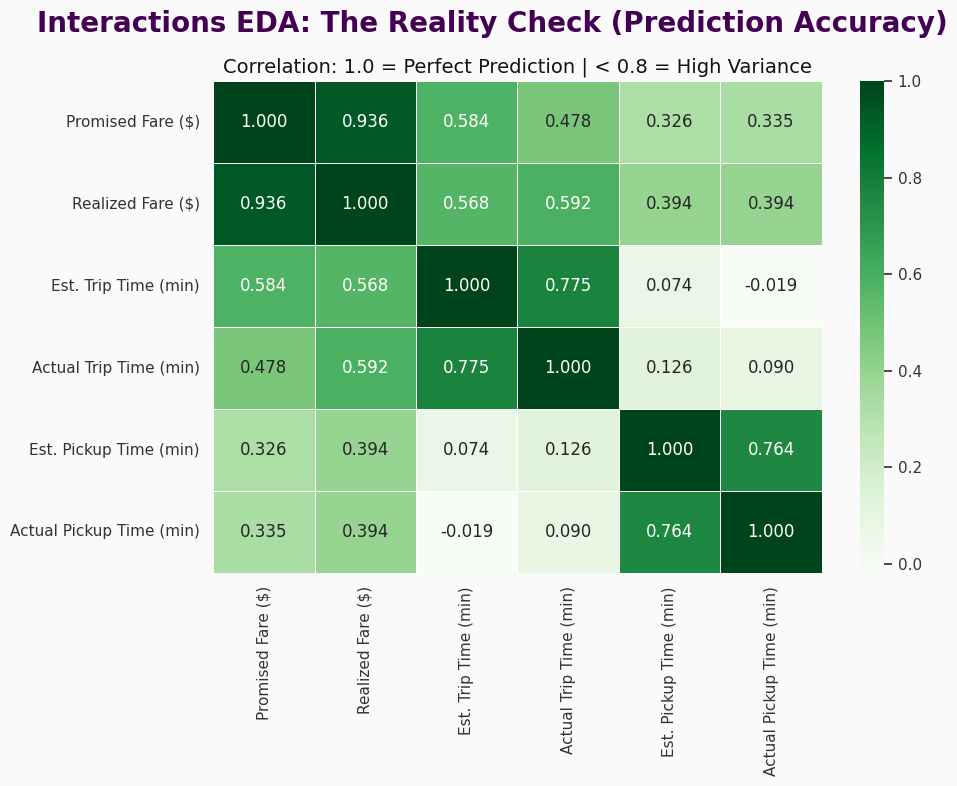

: 

In [ ]:
# ==============================================================================
# CELL 6: THE REALITY CHECK MATRIX (PROMISE VS. EXECUTION)
# ==============================================================================
# Purpose: To audit the accuracy of the platform's predictions.
#          Validates the "Gig Economy Risk Transfer Thesis".
# ==============================================================================

print("⏳ Auditing Promise vs Reality (Completed Missions)...")

query = """
SELECT
    o.upfront_fare             AS "Promised Fare ($)",
    kpi.realized_fare          AS "Realized Fare ($)",
    (o.est_trip_time_sec / 60) AS "Est. Trip Time (min)",
    (kpi.duration_trip_sec / 60) AS "Actual Trip Time (min)",
    (o.time_to_pickup_sec / 60) AS "Est. Pickup Time (min)",
    (kpi.duration_to_pickup_sec / 60) AS "Actual Pickup Time (min)"
FROM v_mission_dossier kpi
JOIN offers o ON kpi.offer_id = o.offer_id
WHERE o.upfront_fare IS NOT NULL
  AND kpi.realized_fare IS NOT NULL
"""
df_reality = pd.read_sql(query, db_engine).dropna()

print(f"✅ Auditing {len(df_reality)} completed missions.")

# 2. CALCULATE CORRELATION
corr_matrix_real = df_reality.corr(method='pearson')

# 3. PLOTTING CONFIGURATION
fig, ax = plt.subplots(figsize=(10, 8))
fig.suptitle('Interactions EDA: The Reality Check (Prediction Accuracy)', fontsize=20, color=OPUS_PURPLE, weight='bold', y=0.98)

# 4. HEATMAP
sns.heatmap(
    corr_matrix_real,
    annot=True,
    fmt=".3f",
    cmap='Greens', # Verde para "Verdad/Precisión"
    cbar=True,
    linewidths=0.5,
    linecolor='white',
    ax=ax
)

ax.set_title("Correlation: 1.0 = Perfect Prediction | < 0.8 = High Variance", fontsize=14)
plt.tight_layout()
plt.show()

## 🛑 **STOP:** The Eureka Moment (`Heatmap Correlation`)

### **Context: The "Reality Check"**
During the `Interactions EDA` module, a global correlation heatmap (see visualization above) was generated to audit the integrity of the platform's predictive signals.

### **The Signal:**
A specific cell in the matrix triggered an immediate red flag:
*   **Correlation(`Est. Trip Time` vs. `Actual Trip Time`) = `0.768`**

In most datasets, `0.768` is a "strong" correlation. **In this domain, it is a catastrophic signal.**
It implies that the platform's core prediction of labor effort (`Est. Trip Time`) explains only ~59% ($R^2$) of the variance in the actual realized labor (`Actual Trip Time`).

**Comparison for Context:**
*   `Promised Fare` vs. `Realized Fare` = `0.887` (Financial stability is relatively high).
*   `Estimated Time` vs. `Realized Time` = `0.768` (Operational stability is significantly lower).

### **The Breakthrough Hypothesis ("The Transfer of Variance"):**
This disparity (`0.887` vs. `0.768`) is the "smoking gun" of the **Gig Economy Risk Transfer Thesis.**
1.  **The Platform hedges the Price:** It maintains high correlation on the fare to keep the driver's financial trust relatively stable.
2.  **The Platform floats the Time:** It allows significant variance in the trip duration to be absorbed by the driver.

**If the Price is fixed but the Time expands, the Driver's hourly wage (`EPH`) collapses.**

### **Strategic Action Triggered:**
This single datapoint halted the linear progression of the EDA. It mandated the immediate creation of the **"Promise vs. Reality" SQL Analysis** (`Double Spread Analysis`) to calculate the granular `time_spread` for every trip. This pivot is the origin point of the **"Algorithmic Deductible"** analytical campaign.

### 💎 Strategic Breakthrough: The "Variance Deductible"

**The Correction:**
Profitability in high-traffic zones is NOT impossible, provided the friction is **predicted and priced** at the moment of the offer (Priced Entropy).

**The Real Trap (Unpriced Volatility):**
The danger lies in **Prediction Error**. The forensic analysis of `Time Spread` (Actual / Estimated) reveals that the platform transfers the risk of *unexpected* delays to the driver up to a specific threshold.

1.  **The Deductible Zone (1.0x to ~1.3x Time):**
    *   If a trip takes **up to 30% longer** than the initial quote (due to an accident, rain, or bad GPS data), the fare remains fixed.
    *   **Implication:** The Agent fully absorbs the cost of this "Surprise Friction."

2.  **Strategic Verdict:**
    The deadliest zones are not necessarily those with the highest traffic (Gridlock), but those with the **least predictable traffic** (High Variance). A slow but stable commute is profitable. A volatile route where 20 minutes can turn into 40 minutes is a financial gamble where the driver holds the downside risk and the platform holds the deductible.

⏳ Architecting the Unified DataFrame...
✅ Unified DataFrame created. Shape: (4765, 34)
⏳ Calculating the Grand Unified Correlation Matrix...
✅ Correlation Matrix Calculated.
🎨 Rendering the Mega-Heatmap...


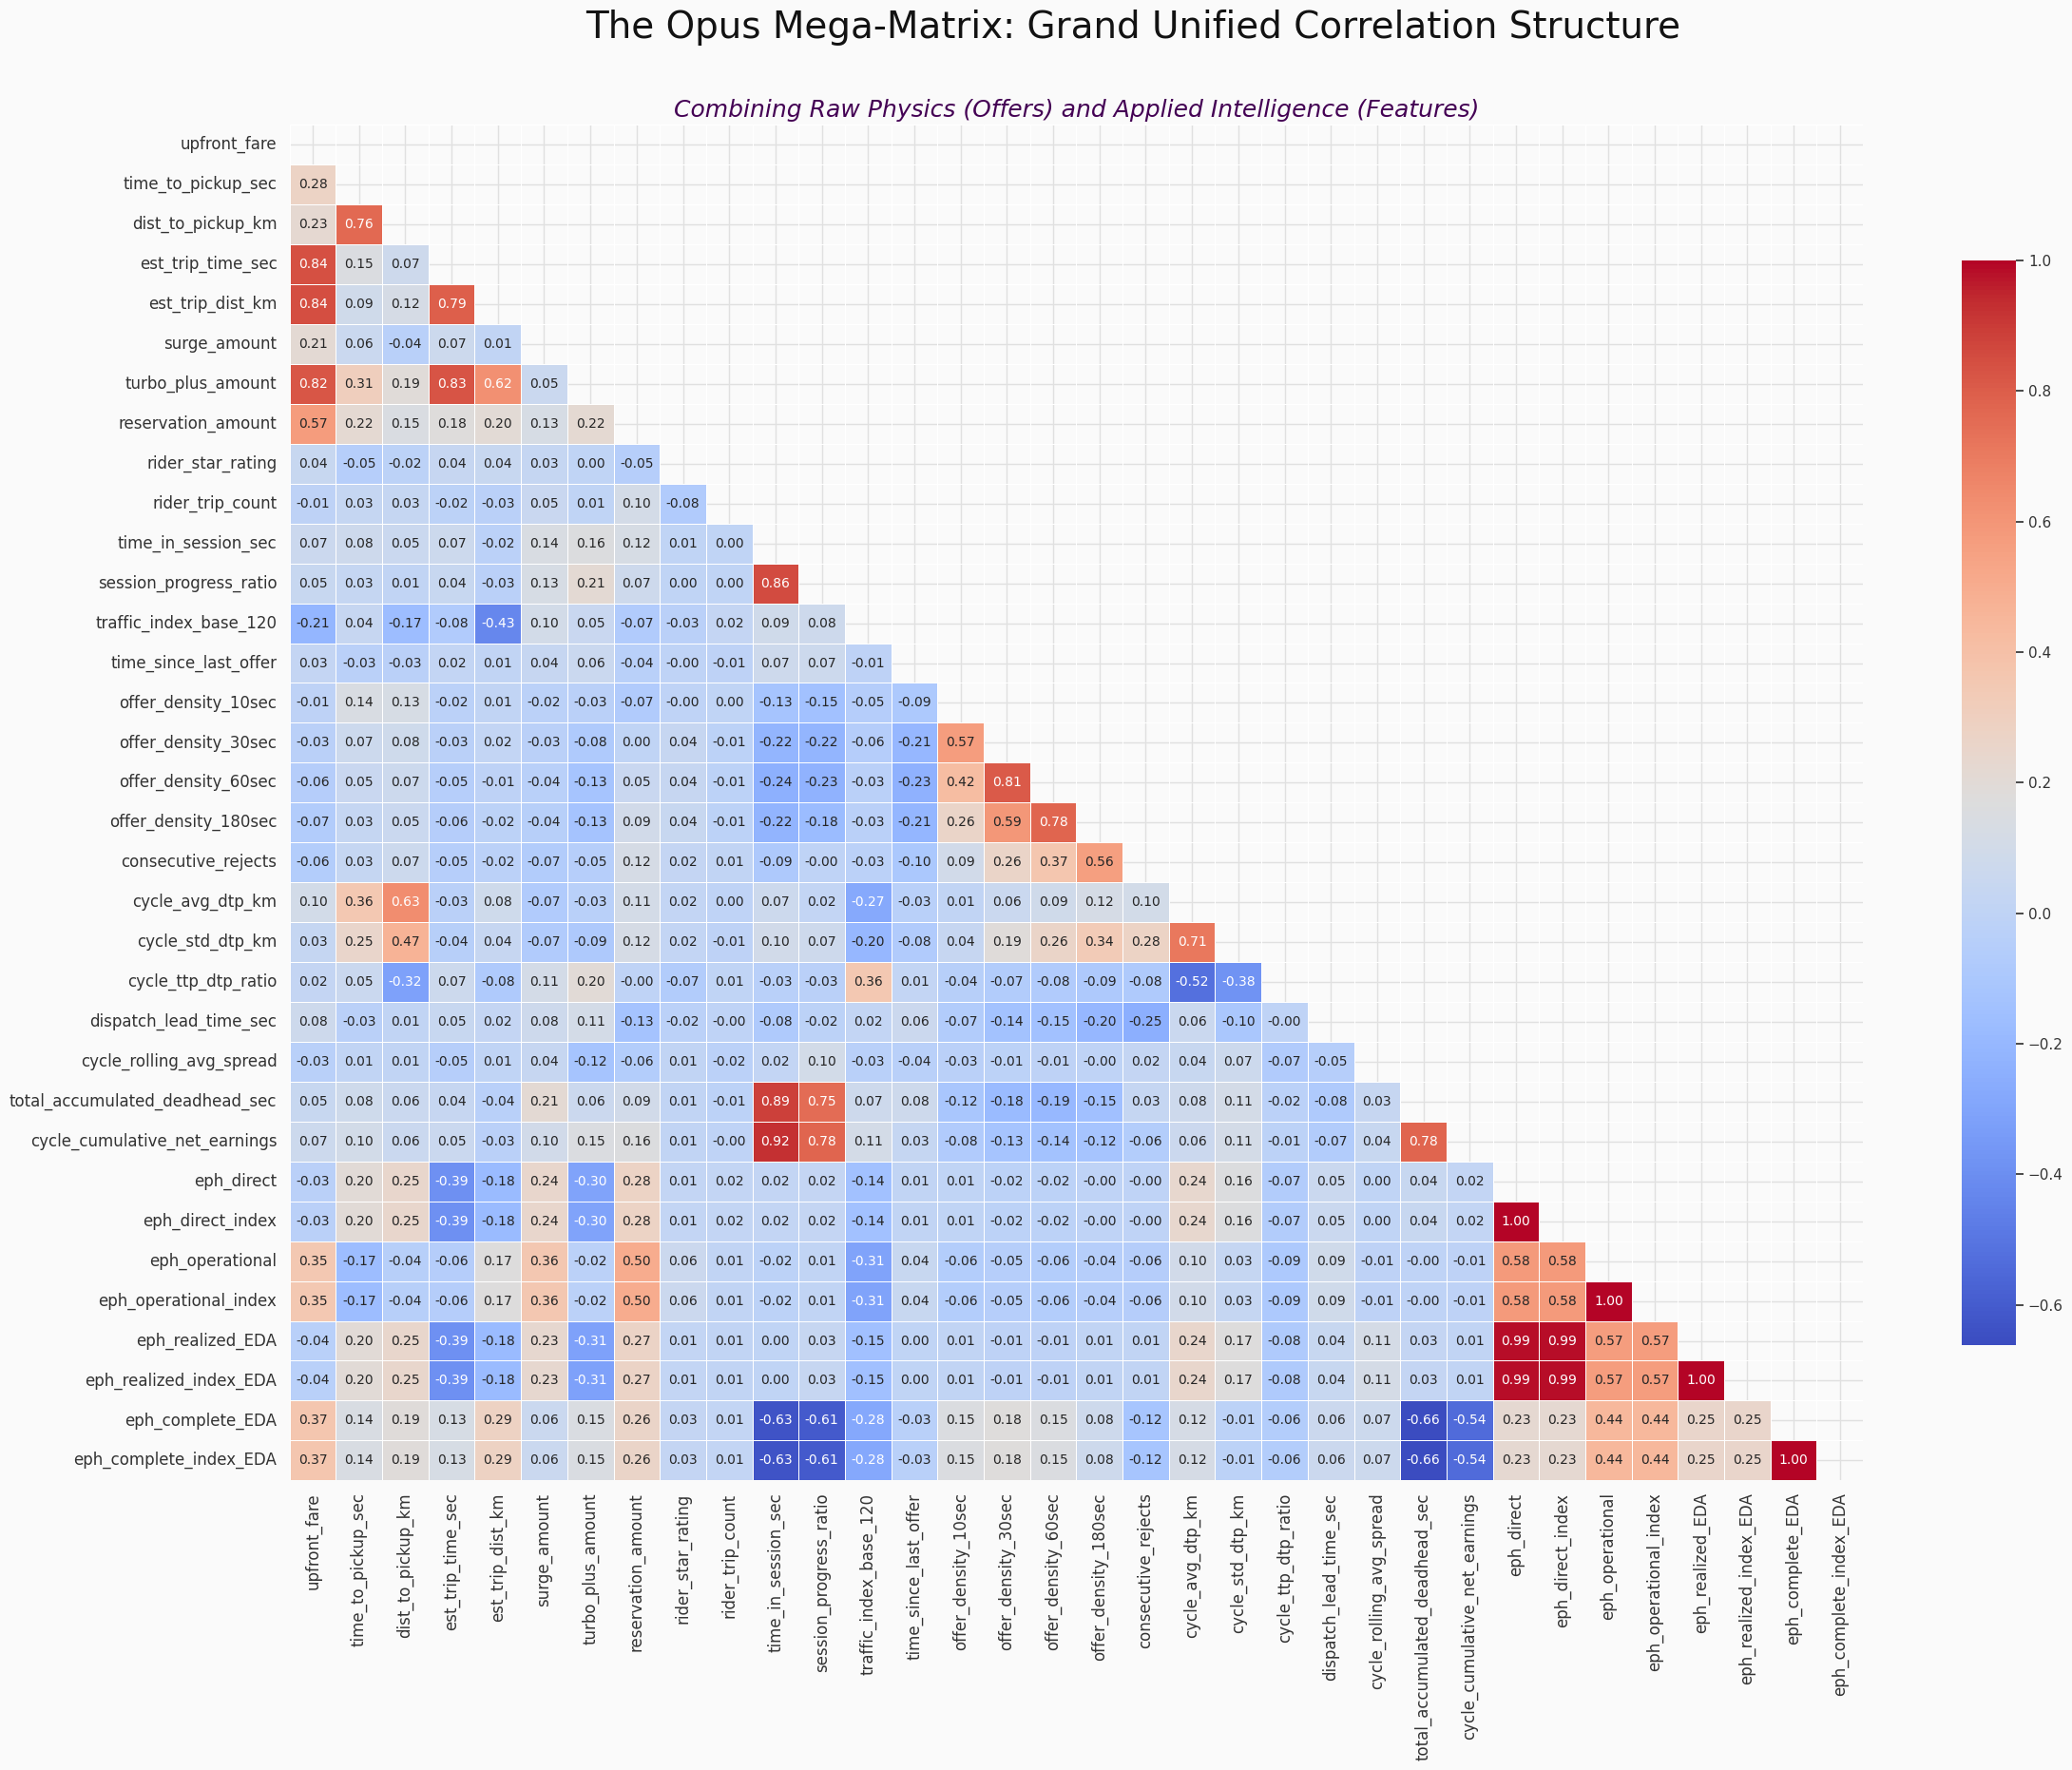


✅ Mega-Matrix Rendered.


In [7]:
# ==============================================================================
# CELL 3: THE GRAND UNIFIED CORRELATION MATRIX (MEGA-HEATMAP)
# ==============================================================================
# Purpose: 1. Join 'offers' and 'engineered_features' to create a unified dataset.
#          2. Calculate the complete correlation matrix for all key numerical vars.
#          3. Visualize this "Mega Matrix" to reveal the total system structure
#             and identify cross-domain relationships.
# ==============================================================================

# --- 1. DATA INGESTION (Unified DataFrame) ---
print("⏳ Architecting the Unified DataFrame...")

# This query selects all numerical columns from your two source heatmaps.
mega_query = """
SELECT
    -- From "Raw Physics" (offers table)
    o.upfront_fare,
    o.time_to_pickup_sec,
    o.dist_to_pickup_km,
    o.est_trip_time_sec,
    o.est_trip_dist_km,
    o.surge_amount,
    o.turbo_plus_amount,
    o.reservation_amount,
    o.rider_star_rating,
    o.rider_trip_count,
    o.time_in_session_sec,
    o.session_progress_ratio,

    -- From "Applied Intelligence" (engineered_features table)
    ef.traffic_index_base_120,
    ef.time_since_last_offer,
    ef.offer_density_10sec,
    ef.offer_density_30sec,
    ef.offer_density_60sec,
    ef.offer_density_180sec,
    ef.consecutive_rejects,
    ef.cycle_avg_dtp_km,
    ef.cycle_std_dtp_km,
    ef.cycle_ttp_dtp_ratio,
    ef.dispatch_lead_time_sec,
    ef.cycle_rolling_avg_spread,
    ef.total_accumulated_deadhead_sec,
    ef.cycle_cumulative_net_earnings,
    ef.eph_direct,
    ef.eph_direct_index,
    ef.eph_operational,
    ef.eph_operational_index,
    ef.eph_realized_EDA,
    ef.eph_realized_index_EDA,
    ef.eph_complete_EDA,
    ef.eph_complete_index_EDA

FROM offers o
LEFT JOIN engineered_features ef ON o.offer_id = ef.offer_id_fk
"""

df_mega = pd.read_sql(mega_query, db_engine)
print(f"✅ Unified DataFrame created. Shape: {df_mega.shape}")


# --- 2. CORRELATION CALCULATION ---
print("⏳ Calculating the Grand Unified Correlation Matrix...")
corr_matrix = df_mega.corr()
print("✅ Correlation Matrix Calculated.")


# --- 3. VISUALIZATION ---
print("🎨 Rendering the Mega-Heatmap...")

# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Set up the matplotlib figure (large to accommodate all features)
plt.figure(figsize=(24, 20))

# Draw the heatmap
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap='coolwarm',       # Diverging colormap for correlations
    annot=True,            # Show the correlation values
    fmt='.2f',             # Format values to two decimal places
    linewidths=.5,
    cbar_kws={"shrink": .8},
    annot_kws={"size": 10} # Adjust font size for readability
)

# --- 4. AESTHETICS & TITLES ---
plt.suptitle("The Opus Mega-Matrix: Grand Unified Correlation Structure", fontsize=28, y=0.96)
plt.title("Combining Raw Physics (Offers) and Applied Intelligence (Features)", fontsize=18, style='italic', color=OPUS_PURPLE)
plt.xticks(rotation=90, fontsize=12)
plt.yticks(rotation=0, fontsize=12)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("\n✅ Mega-Matrix Rendered.")